# 🏠 Tehran House Price Prediction

A machine learning project that predicts house prices in Tehran using a single, carefully tuned CatBoost model.

This notebook is the analytical/educational version of the project: it walks through exploratory data analysis (EDA), the domain-knowledge feature engineering used to encode Tehran's real estate geography, leakage-free target encoding, and 5-fold cross-validation, matching the current `main.py` pipeline.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv("tehranHprice.csv")
df.head()


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3473 entries, 0 to 3472
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3473 non-null   int64  
 1   Room        3473 non-null   int64  
 2   Parking     3473 non-null   bool   
 3   Warehouse   3473 non-null   bool   
 4   Elevator    3473 non-null   bool   
 5   Address     3450 non-null   object 
 6   Price       3473 non-null   float64
 7   Price(USD)  3473 non-null   float64
dtypes: bool(3), float64(2), int64(2), object(1)
memory usage: 146.0+ KB


In [4]:
df.isnull().sum()


Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

**23 missing values** exist in the `Address` column, and **113 duplicate records** exist in the dataset. Unlike a typical cleaning pass, neither of these is dropped here — see **Section 3** for why.

## 3. Data Cleaning Decisions

- **Missing `Address` values are filled with `"missing"`**, not dropped, so these rows aren't lost entirely.
- **Duplicate records are intentionally kept.** In the real estate market, seemingly duplicate rows can represent different units or floors within the same building that naturally share the same address, area, and structural features. Dropping them as duplicates would discard valid market information rather than noise.
- Only rows with `Price <= 0` are removed, since these are clearly invalid entries rather than legitimate low-price listings.

In [5]:
df["Address"] = df["Address"].fillna("missing")
df = df[df["Price"] > 0]

print("Shape after cleaning:", df.shape)


Shape after cleaning: (3473, 8)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Price Distribution

We compare the price distribution before and after the log transform to see why `log1p` is used.

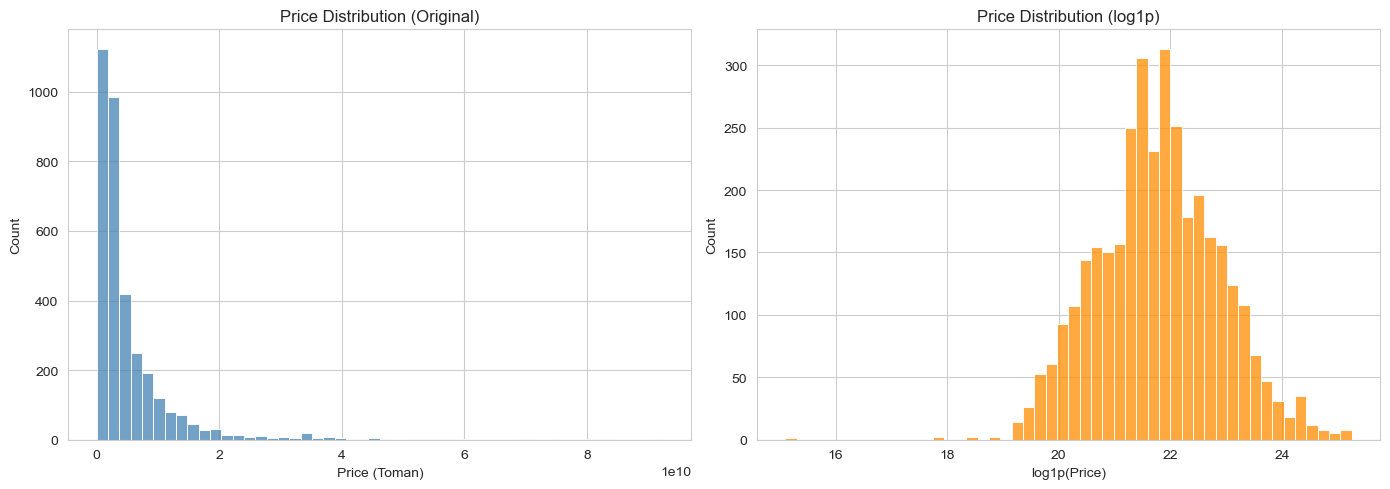

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Price"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution (Original)")
axes[0].set_xlabel("Price (Toman)")

sns.histplot(np.log1p(df["Price"]), bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Price Distribution (log1p)")
axes[1].set_xlabel("log1p(Price)")

plt.tight_layout()
plt.show()


📌 The original price distribution is strongly **right-skewed** (few very expensive houses, most cheaper). Rather than using IQR-based filtering to remove extreme values, `log1p` is used instead — Tehran's housing market is highly skewed and sometimes irrational, and IQR-based limits would remove legitimate large or expensive properties along with genuine outliers. The `log1p` transform reduces the impact of extreme values while preserving all observations for the model to learn from.

### 4.2 Area vs Price

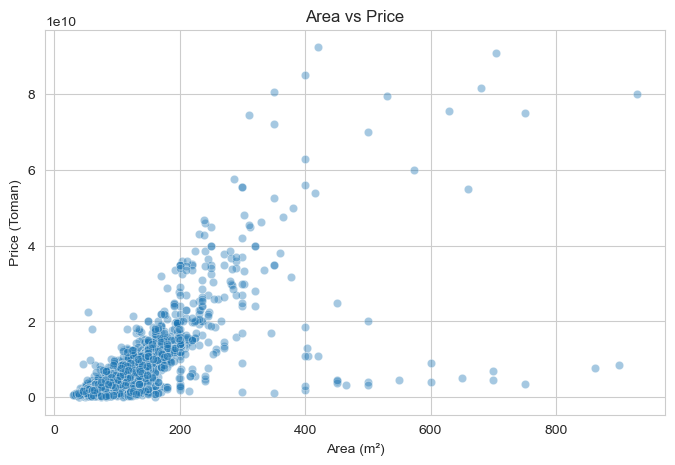

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Area", y="Price", alpha=0.4)
plt.title("Area vs Price")
plt.xlabel("Area (m²)")
plt.ylabel("Price (Toman)")
plt.show()


📌 An overall positive relationship between area and price is visible, but there are a few outliers with very large area or unusual price.

### 4.3 Effect of Amenities (Parking / Warehouse / Elevator) on Price

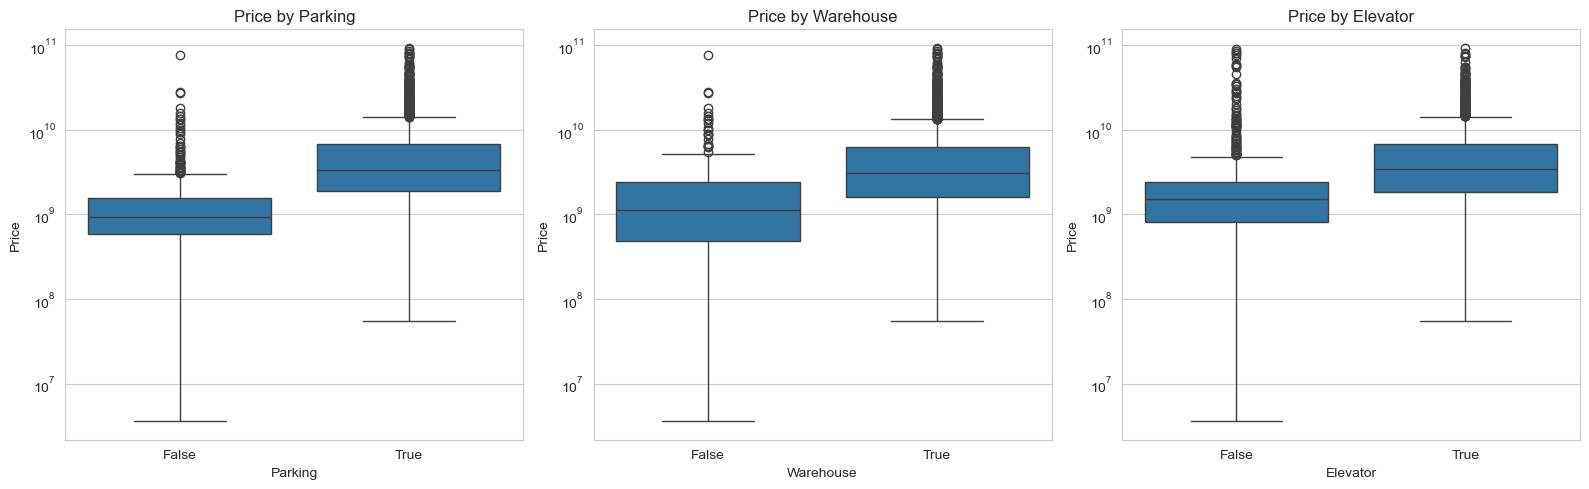

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, col in zip(axes, ["Parking", "Warehouse", "Elevator"]):
    sns.boxplot(data=df, x=col, y="Price", ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


📌 For all three features, houses with the amenity (value 1) have a higher median price than those without; parking and elevator show a more noticeable effect.

### 4.4 Top 15 Most Expensive Neighborhoods (by Average Price)

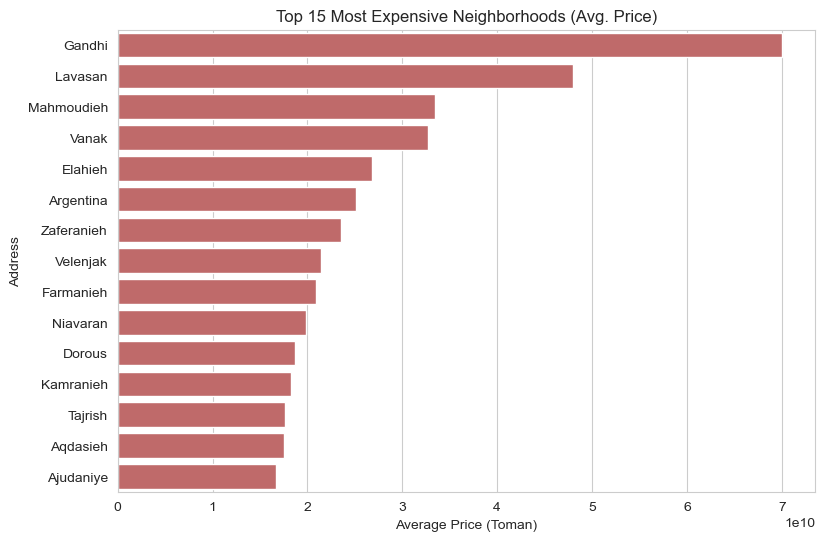

In [9]:
top_addresses = (
    df.groupby("Address")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9,6))
sns.barplot(x=top_addresses.values, y=top_addresses.index, color="indianred")
plt.title("Top 15 Most Expensive Neighborhoods (Avg. Price)")
plt.xlabel("Average Price (Toman)")
plt.ylabel("Address")
plt.show()


📌 Price varies enormously by neighborhood — this is the core motivation behind the district-level feature engineering in the next section: `Address` alone is a very high-cardinality feature, and mapping it to Tehran's official municipal districts gives the model a coarser, more generalizable notion of location.

### 4.5 Correlation Matrix of Numeric Features

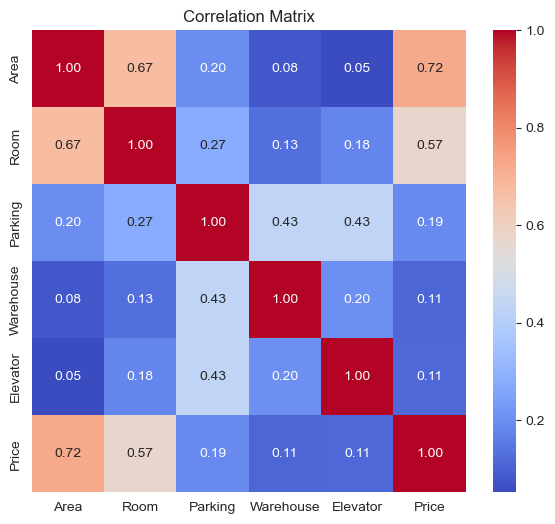

In [10]:
numeric_cols = ["Area", "Room", "Parking", "Warehouse", "Elevator", "Price"]

plt.figure(figsize=(7,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


📌 `Area` has the strongest linear correlation with `Price`. The binary features (Parking/Warehouse/Elevator) show weaker correlation, but as seen in the box plots, their effect is non-linear and meaningful in interaction with other features.

## 5. Domain-Knowledge Feature Engineering

The raw dataset has no official municipal district number, even though district is one of the strongest price drivers in the real Tehran housing market. Four features are engineered here to encode this kind of domain knowledge directly:

- **`district_number`** — each neighborhood in `Address` is manually mapped to its corresponding municipal district (1–22), based on real knowledge of Tehran's district boundaries.
- **`is_suburb`** — neighborhoods outside Tehran's formal district system (e.g. Pardis, Islamshahr, Parand) are flagged as a separate binary feature.
- **`top_area`** — EDA (not shown in this notebook, but discovered during development) revealed that properties over 120 m² located in districts 1, 2, or 3 form a distinct premium segment with a substantial price gap versus the rest of the data. This nonlinear pattern is captured explicitly as its own feature.
- **`facility_score`** — a simple sum of `Room`, `Parking`, `Elevator`, and `Warehouse`, giving a single numeric measure of a property's overall amenity level.
- **`area_per_room`** — the ratio of `Area` to `Room`, capturing average room size. Two houses with the same total area but a different number of rooms often have different market value, and this ratio helps the model tell them apart.

In [11]:
neighborhood_to_district = {
    # District 1
    'Velenjak': 1, 'Zaferanieh': 1, 'Niavaran': 1, 'Kamranieh': 1, 'Aqdasieh': 1, 'Sohanak': 1,
    'Darband': 1, 'Darakeh': 1, 'Tajrish': 1, 'Farmanieh': 1, 'Ozgol': 1, 'Gheitarieh': 1,
    'Araj': 1, 'Dezashib': 1, 'Ekhtiarieh': 1, 'Hekmat': 1, 'Mahallati': 1, 'Elahieh': 1,
    'Mahmoudieh': 1, 'Ajudaniye': 1, 'Chidz': 1,

    # District 2
    'Shahrake Gharb': 2, 'Marzdaran': 2, 'Punak': 2, 'Sadeghieh': 2, 'Shahrake Qods': 2,
    'Saadat Abad': 2, 'ShahrAra': 2, 'Gisha': 2, 'Sattarkhan': 2, 'Daryan No': 2,
    'Tarasht': 2, 'Telecommunication': 2, 'Shahrake Quds': 2,

    # District 3
    'Vanak': 3, 'Jordan': 3, 'Mirdamad': 3, 'Zafar': 3, 'Gholhak': 3, 'Zargandeh': 3,
    'Dorous': 3, 'Pasdaran': 3, 'Ghoba': 3, 'Seyed Khandan': 3,

    # ... the full mapping (all 22 districts) lives in main.py; only a sample is shown here
}

df['district_number'] = df['Address'].map(neighborhood_to_district)


> 📝 The full mapping in `main.py` covers all 22 municipal districts and dozens of neighborhoods; only a representative sample is reproduced here to illustrate the approach without duplicating the entire lookup table.

In [12]:
suburb = {
    'Pardis', 'Islamshahr', 'Parand', 'Pakdasht', 'Pakdasht KhatunAbad', 'Shahryar',
    'Rudhen', 'Chahardangeh', 'Baqershahr', 'Kahrizak', 'Qarchak', 'Damavand', 'Absard',
    'Lavasan', 'Shahedshahr', 'Nasim Shahr', 'Chardangeh', 'Tenant', 'Malard', 'SabaShahr',
    'Pishva', 'Islamshahr Elahieh', 'Ray - Montazeri', 'Firoozkooh Kuhsar', 'Robat Karim',
    'Ray - Pilgosh', 'Ghiyamdasht', 'Safadasht', 'Khademabad Garden', 'Mehrabad River River',
    'Varamin - Beheshti', 'Alborz Complex', 'Firoozkooh'
}
pattern = '|'.join(suburb)
df['is_suburb'] = df['Address'].str.contains(pattern, case=False, na=False)

df["top_area"] = False
mask = (df["Area"] > 120) & (df["district_number"].isin([1, 2, 3]))
df.loc[mask, "top_area"] = True

df['facility_score'] = df["Room"] + df["Parking"].astype(int) + df["Elevator"].astype(int) + df["Warehouse"].astype(int)

df['area_per_room'] = df['Area'] / df['Room']

df[["Address", "district_number", "is_suburb", "top_area", "facility_score", "area_per_room"]].head()


,Address,district_number,is_suburb,top_area,facility_score,area_per_room
0,Shahran,NaN,False,False,4,63.0
1,Shahran,NaN,False,False,4,60.0
2,Pardis,NaN,True,False,5,39.5
3,Shahrake Qods,2.0,False,False,5,47.5
4,Shahrake Gharb,2.0,False,True,5,61.5


### 5.1 Average Price by District

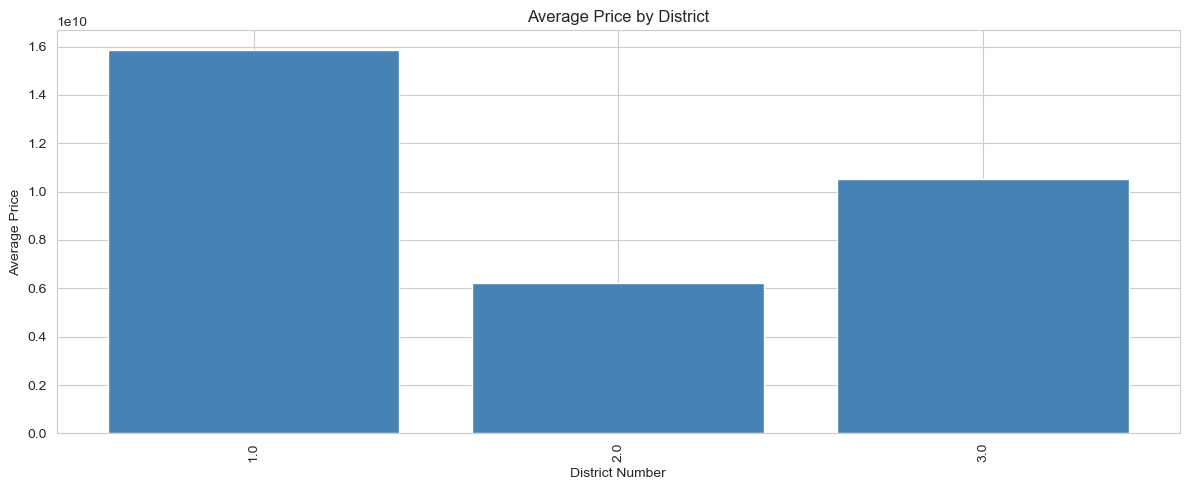

In [13]:
district_stats = df.groupby("district_number")["Price"].mean().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(district_stats.index.astype(str), district_stats.values, color="steelblue")
plt.xlabel("District Number")
plt.ylabel("Average Price")
plt.title("Average Price by District")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


📌 Average price varies substantially by district, confirming that `district_number` captures real, usable signal rather than just being a categorical relabeling of `Address`.

### 5.2 `facility_score` and `area_per_room` vs Price

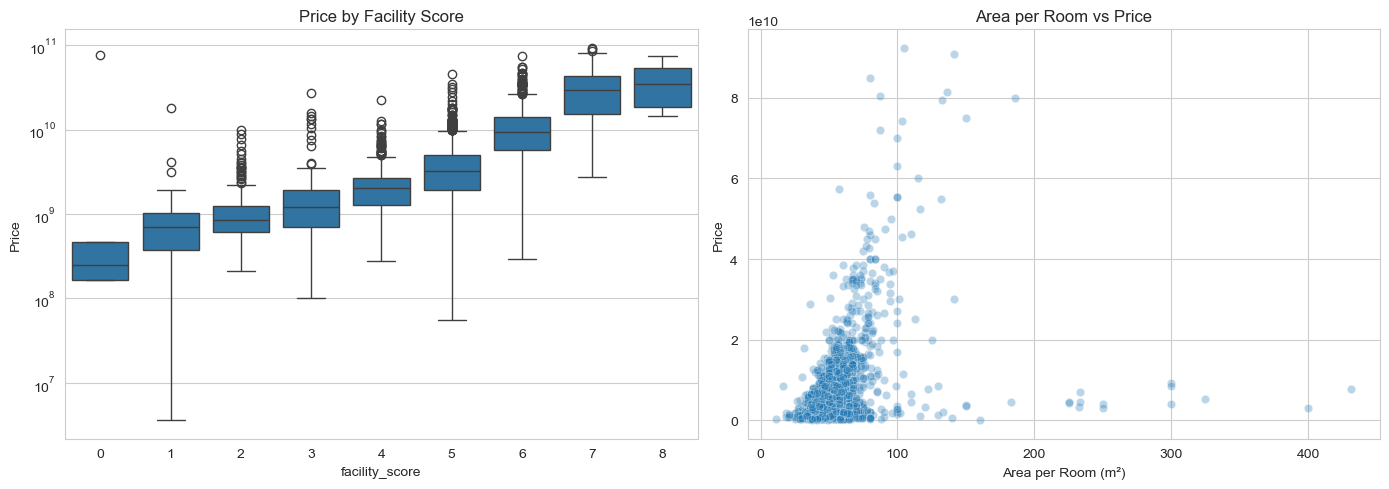

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="facility_score", y="Price", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by Facility Score")

sns.scatterplot(data=df, x="area_per_room", y="Price", alpha=0.3, ax=axes[1])
axes[1].set_title("Area per Room vs Price")
axes[1].set_xlabel("Area per Room (m²)")

plt.tight_layout()
plt.show()


📌 Price tends to rise with `facility_score`, confirming it's a reasonable single-number summary of amenities. `area_per_room` shows a positive relationship with price too — houses with larger rooms (higher area per room) tend to be worth more, even at the same total area.

## 6. Encoding Strategy

`Address`, `district_number`, and `is_suburb` are passed to CatBoost as **categorical** features (via `cat_features`), not one-hot encoded. These are independent categories rather than ordered numerical values, and CatBoost's native categorical handling lets the model learn a separate representation for each category without assuming any ranking between them or expanding the feature space with dummy columns.

Before this, `district_number` needs a small cleanup: missing values are filled with `0`, converted to integer (to drop decimal artifacts like `2.0` → `2`), then converted to string so it's treated as categorical rather than continuous.

In [15]:
cat_feature = ["Address", "district_number", "is_suburb"]

df["district_number"] = (
    df["district_number"]
      .fillna(0)
      .astype(int)
      .astype(str)
)

x = df.drop(columns=["Price", "Price(USD)"])
y = np.log1p(df["Price"])


## 7. Train / Test Split

In [16]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.1, random_state=42)

print("Train shape:", train_x.shape)
print("Test shape :", test_x.shape)


Train shape: (3125, 11)
Test shape : (348, 11)


## 8. Leakage-Free Target Encoding

`district_number` also gets a **smoothed target encoding**: each district's mean log-price is blended with the overall dataset mean, so districts with very few listings get pulled toward the global average instead of overfitting to a handful of data points. Districts unseen during training fall back to the global mean entirely.

The encoding is always **fit on the training portion only** and then applied to the corresponding validation/test portion — this function is called once for the main train/test split, and again independently inside each fold of the cross-validation below, so no validation or test row ever influences its own encoded value.

In [17]:
def target_encoding(X_train, X_valid, y_train, m=50):
    train_df = X_train.copy()
    train_df["target"] = y_train

    global_mean = train_df["target"].mean()

    stats = train_df.groupby("district_number")["target"].agg(["mean", "count"])
    stats["smooth"] = (stats["count"] * stats["mean"] + m * global_mean) / (stats["count"] + m)

    X_train = X_train.copy()
    X_valid = X_valid.copy()

    X_train["district_target_mean"] = X_train["district_number"].map(stats["smooth"])
    X_valid["district_target_mean"] = X_valid["district_number"].map(stats["smooth"])

    X_train["district_target_mean"] = X_train["district_target_mean"].fillna(global_mean)
    X_valid["district_target_mean"] = X_valid["district_target_mean"].fillna(global_mean)

    return X_train, X_valid


train_x, test_x = target_encoding(train_x, test_x, train_y)
train_x[["district_number", "district_target_mean"]].head()


,district_number,district_target_mean
1720,0,21.377244
621,0,21.377244
1075,0,21.377244
1951,2,22.110813
2949,0,21.377244


## 9. Model Configuration

A single **CatBoostRegressor** is used — no model comparison or `GridSearchCV` sweep in this version of the pipeline. The hyperparameters below reflect the values currently used in `main.py`.

In [18]:
model_reg = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.02,
    depth=4,
    l2_leaf_reg=1,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=100,
    verbose=False,
)


## 10. 5-Fold Cross Validation

The training data is split into 5 folds. In each iteration:

1. One fold is held out for validation; the remaining four are used for training.
2. Target encoding is recomputed **using only that iteration's training fold**, to prevent leakage from the validation fold.
3. CatBoost is trained on the training fold and evaluated on the validation fold with R².

The mean and standard deviation of the five R² scores estimate the model's generalization performance and stability.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, valid_idx in kf.split(train_x):
    X_train = train_x.iloc[train_idx].copy()
    X_valid = train_x.iloc[valid_idx].copy()
    y_train = train_y.iloc[train_idx]
    y_valid = train_y.iloc[valid_idx]

    X_train, X_valid = target_encoding(X_train, X_valid, y_train)

    model_reg.fit(X_train, y_train, cat_features=cat_feature, verbose=False)
    pred = model_reg.predict(X_valid)
    scores.append(r2_score(y_valid, pred))

print("Fold R²:", scores)
print("Mean CV R²:", np.mean(scores))
print("Std CV R²:", np.std(scores))


## 11. Train Final Model

In [ ]:
model_reg.fit(train_x, train_y, cat_features=cat_feature, verbose=False)

trainlog_pred = model_reg.predict(train_x)
model_pred = model_reg.predict(test_x)

train_r2 = r2_score(np.expm1(train_y), np.expm1(trainlog_pred))
test_r2 = r2_score(np.expm1(test_y), np.expm1(model_pred))
rmse = np.sqrt(mean_squared_error(np.expm1(test_y), np.expm1(model_pred)))

print(f"R² (train): {train_r2:0.2%}")
print(f"R² (test) : {test_r2:0.2%}")
print(f"RMSE      : {rmse:,.0f}")


### 11.1 Actual vs Predicted

In [ ]:
plt.figure(figsize=(7,7))
actual = np.expm1(test_y)
predicted = np.expm1(model_pred)

plt.scatter(actual, predicted, alpha=0.4, color="steelblue")
max_val = max(actual.max(), predicted.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (CatBoost)")
plt.legend()
plt.show()


📌 The closer the points are to the red line (perfect prediction), the more accurate the model. More scatter at higher prices shows the model has higher error for the most expensive properties — consistent with the long right tail seen in the price distribution earlier.

### 11.2 Feature Importance

In [ ]:
importances = pd.Series(
    model_reg.get_feature_importance(),
    index=train_x.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, color="seagreen")
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.show()


📌 `Area` is the single most important feature, but location-related features — `Address`, `district_number`, `district_target_mean`, and `is_suburb` — together account for a large share of importance right behind it, confirming that the domain-knowledge geographic features are doing real work rather than duplicating what `Address` already provides.

## 12. Summary

- **Mean CV R²**: 0.8829 (Std: 0.0235)
- **R² (train)**: 90.38%
- **R² (test)**: 85.73%
- **RMSE (test)**: 2,453,876,315

Key decisions behind this version of the pipeline:

- Missing `Address` values and duplicate rows are preserved rather than dropped, avoiding the loss of real market information.
- Location is encoded through three complementary features (`Address`, `district_number`, `is_suburb`) plus a leakage-free target encoding, rather than relying on `Address` alone.
- `top_area`, `facility_score`, and `area_per_room` translate domain knowledge about Tehran's housing market into features the model can use directly.
- A single, well-tuned CatBoost model is used instead of comparing several algorithms, with 5-fold cross-validation (using leakage-free target encoding per fold) as the main measure of generalization.